In [1]:
#import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
# This additional steps allow to maintain data reailbility as each time we restart kernal data from .xlsx append same data each time.
# SO this help to keep the existing data in main .db and remove the appended .xlsx so we can re-append that

"""
conn = sqlite3.connect('customer_churn.db')
cursor = conn.cursor()

# Keep index 0–20 => keep first 21 rows
cursor.execute("""
    DELETE FROM customer
    WHERE rowid NOT IN (
        SELECT rowid
        FROM customer
        LIMIT 21
    );
""")

# Keep index 0–20 => keep first 21 rows
cursor.execute("""
    DELETE FROM subscription
    WHERE rowid NOT IN (
        SELECT rowid
        FROM subscription
        LIMIT 21
    );
""")

# Keep index 0–8 => keep first 9 rows
cursor.execute("""
    DELETE FROM support
    WHERE rowid NOT IN (
        SELECT rowid
        FROM support
        LIMIT 9
    );
""")

conn.commit()

print("Data deleted successfully.")

conn.close()




"""

In [2]:
#1. Database import

In [3]:
# Appending the data before import as customer_churn.db doesn't contain the whole dataset

conn = sqlite3.connect('customer_churn.db')

# 1. Read the new Excel files

new_customer = pd.read_excel('db_customer_new.xlsx')
new_subscription = pd.read_excel('db_subscription_new.xlsx')
new_support = pd.read_excel('db_support_new.xlsx')


# 2. Append new data to SQLite tables

new_customer.to_sql(
    'db_customer',
    conn,
    if_exists='append',
    index=False
)

new_subscription.to_sql(
    'db_subscription',
    conn,
    if_exists='append',
    index=False
)

new_support.to_sql(
    'db_support',
    conn,
    if_exists='append',
    index=False
)

print("New data successfully added to SQLite database.")

New data successfully added to SQLite database.


In [4]:
conn = sqlite3.connect('customer_churn.db')
sql_query = '''
            SELECT Name
            FROM sqlite_master
            WHERE type = 'table';
            '''
tables = pd.read_sql(sql_query,conn)

#Create the dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f'SELECT * FROM {table_name}',conn)
    globals()[f'df_{table_name}'] = df
    print(f'Created Datafram: df_{table_name}')

Created Datafram: df_db_customer
Created Datafram: df_db_subscription
Created Datafram: df_db_support


In [5]:
#table name and Column names
conn = sqlite3.connect('customer_churn.db')
for names in tables['name']:
    print(f'\n Table Name: {names}')
    columns_query = f'PRAGMA table_info ({names})'
    columns = pd.read_sql(columns_query,conn)
    print('Columns: ')
    print(columns['name'].tolist())

conn.close


 Table Name: db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name: db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name: db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


<function Connection.close()>

In [6]:
# 2. Data Cleaning

In [7]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
116,0119-KYEUI,jatin,India,Telangana,Female,1991-06-03 00:00:00,None,515124.0
117,0120-FXORW,yash,India,Meghalaya,Female,1993-12-19 00:00:00,None,531115.0
118,0121-NRADC,sandeep,India,Rajasthan,Male,1995-05-12 00:00:00,None,534449.0
119,0122-WERBL,omkar,Nepal,Kathmandu,Male,1999-04-22 00:00:00,None,532403.0
120,0123-SRENE,ravi,India,Nagaland,Female,1977-09-15 00:00:00,None,516150.0


In [8]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  121 non-null    object 
 1   name        121 non-null    object 
 2   country     118 non-null    object 
 3   state       121 non-null    object 
 4   gender      121 non-null    object 
 5   dob         121 non-null    object 
 6   interests   4 non-null      object 
 7   pincode     100 non-null    float64
dtypes: float64(1), object(7)
memory usage: 7.7+ KB


In [9]:
# a. Rename the Column - name
# b. Drop the interests & pincode
# c. Fixing datatype - dob
# d. Data standardization - gender
# e. Filling the missing value - country

In [10]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN


In [11]:
# a. Rename the Column - name
df_db_customer.rename(columns = {'name' : 'customer_name'},inplace = True)

In [12]:
# b. Drop the interests & pincode
#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
df_db_customer.drop(columns = ['interests','pincode'],inplace = True)

In [13]:
# c. Fixing datatype - dob
df_db_customer['dob'] = pd.to_datetime(
    df_db_customer['dob'],
    format='mixed',
    dayfirst=True
)

In [14]:
# d. Data standardization - gender
# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male','Women' : 'Female'})

In [15]:
# e. Filling the missing value - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [16]:
state_country_map = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_map))

In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription['customerid'].count()

np.int64(121)

In [19]:
df_db_support.head(21)

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund
9,0025-HHEXD,2022-04-23 00:00:00,Y,30,None,None


In [20]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               121 non-null    object 
 1   subscription_start_date  121 non-null    object 
 2   subscription_type        121 non-null    object 
 3   renewal_date             121 non-null    object 
 4   plan_type                121 non-null    object 
 5   contract_type            121 non-null    object 
 6   cancellation_date        106 non-null    object 
 7   cancellation_reason      32 non-null     object 
 8   monthly_charges          121 non-null    float64
 9   cltv                     121 non-null    int64  
 10  churn_score              121 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 10.5+ KB


In [21]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [22]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               121 non-null    object        
 1   subscription_start_date  121 non-null    datetime64[ns]
 2   subscription_type        121 non-null    object        
 3   renewal_date             121 non-null    datetime64[ns]
 4   plan_type                121 non-null    object        
 5   contract_type            121 non-null    object        
 6   cancellation_date        32 non-null     datetime64[ns]
 7   cancellation_reason      32 non-null     object        
 8   monthly_charges          121 non-null    float64       
 9   cltv                     121 non-null    int64         
 10  churn_score              121 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 10.5+ KB


In [23]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [24]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      64 non-null     object
 1   complaint_date  64 non-null     object
 2   escalations     64 non-null     object
 3   csat_score      64 non-null     int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 3.1+ KB


In [25]:
df_db_support.drop(columns = ['col_1','comment'],inplace = True)

In [26]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [27]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      64 non-null     object        
 1   complaint_date  64 non-null     datetime64[ns]
 2   escalations     64 non-null     object        
 3   csat_score      64 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 2.1+ KB


In [28]:
# 3. Feature Engineering and Data Analysis

In [29]:
# Create a new column using existing column - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [30]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
df = (df_db_subscription
        .merge(df_db_customer,on = 'customerid',how = 'left')
        .merge(df_db_support,on = 'customerid',how = 'left'))

In [32]:
df.shape

(135, 20)

In [33]:
df_db_subscription.shape

(121, 12)

In [34]:
df_db_subscription['customerid'].nunique()

121

In [35]:
df_db_customer['customerid'].nunique()

121

In [36]:
df_db_support['customerid'].nunique()

50

In [37]:
df_db_support['customerid'].size

64

In [38]:
df_db_support[df_db_support['customerid'].duplicated()]

,customerid,complaint_date,escalations,csat_score
1,0003-MKNFE,2024-08-28,Y,10
8,0022-TCJCI,2024-09-14,N,90
10,0025-HHEXD,2025-03-26,Y,5
12,0032-WNKIE,2023-12-24,N,70
15,0037-JUTLS,2022-06-09,N,49
18,0040-DMIOU,2021-03-13,N,78
21,0044-XHFOM,2023-02-25,N,86
29,0059-YIYUK,2023-05-23,N,74
31,0060-DJNFO,2022-05-20,N,93
43,0090-RACYH,2021-01-01,Y,6


In [39]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
59,0114-DDXRE,2021-06-20,N,64
60,0117-QPIBC,2022-08-03,N,93
61,0117-QPIBC,2021-09-29,N,89
62,0122-WERBL,2022-11-04,N,86


In [40]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [41]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
...,...,...,...,...,...
59,0114-DDXRE,2021-06-20,N,64,1
60,0117-QPIBC,2022-08-03,N,93,2
61,0117-QPIBC,2021-09-29,N,89,2
62,0122-WERBL,2022-11-04,N,86,1


In [42]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [43]:
df_db_support['customerid'].size

50

In [44]:
# Merge DF 
df = (df_db_subscription
            .merge(df_db_customer,on = 'customerid',how = 'left')
            .merge(df_db_support, on = 'customerid',how = 'left'))

In [45]:
df.shape

(121, 21)

In [46]:
df.to_csv('exported_churn_data.csv',index = False)

In [47]:
# Data Analysis

In [48]:
# 1. Churn Analysis

In [49]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [50]:
churn_rate = df['churn_flag'].mean()*100
print("Churn rate = ", round(churn_rate,2),"%")

Churn rate =  26.45 %


In [51]:
# 2. Retenion Rate
retenion_rate = 100-churn_rate
print("Retenion Rate = ", round(retenion_rate,2),'%')

Retenion Rate =  73.55 %


In [52]:
# 3. Churn by plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           36.59
1   Premium           23.68
2  Standard           19.05


In [53]:
# 4. a. Churn by state + sum(revenue) & count of users
churn_by_state = (df.groupby('state')
                    .agg(
                            churn_rate_pct = ('churn_flag', lambda x: x.mean()*100),
                            total_revenue = ('monthly_charges','sum'),
                            user_count = ('customerid','count')
                        )
                        .round({'churn_rate_pct': 2,'total_revenu': 2})
                        .reset_index()
                    )
print(churn_by_state)
                            

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           29.41         560.31          17
1      Karnataka           33.33         310.20          12
2      Kathmandu           45.45         306.54          11
3    Maharashtra           21.43         345.78          14
4      Meghalaya           36.36         168.45          11
5       Nagaland           27.27         202.54          11
6      Rajasthan           28.57         393.89          14
7      Telangana           14.29         343.21          14
8  Uttar Pradesh           11.76         573.89          17


In [54]:
# 4. b. Churn by subscription type + sum(revenue) & count of users
churn_by_subscription_type = (df.groupby('subscription_type')
                    .agg(
                            churn_rate_pct = ('churn_flag', lambda x: x.mean()*100),
                            total_revenue = ('monthly_charges','sum'),
                            user_count = ('customerid','count')
                        )
                        .round({'churn_rate_pct': 2,'total_revenu': 2})
                        .reset_index()
                    )
print(churn_by_subscription_type)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic           14.71         750.10          34
1              Paid           23.08        1124.89          39
2          Refferal           37.50        1329.82          48


In [55]:
#5. ARPU - Avg Revenu pr User
arpu = df['monthly_charges'].mean().round(2)
print('ARPU = ', arpu)

ARPU =  26.49


In [56]:
# Calculate the age of customers
age = {}
for _, row in df.iterrows():
    age[row['customerid']] = (
        pd.Timestamp.today()- pd.to_datetime(row['dob'])
    ).days//365
print(age)

{'0002-ORFBO': 44, '0003-MKNFE': 30, '0004-TLHLJ': 48, '0011-IGKFF': 25, '0013-EXCHZ': 36, '0013-MHZWF': 37, '0013-SMEOE': 49, '0014-BMAQU': 27, '0015-UOCOJ': 41, '0016-QLJIS': 32, '0017-DINOC': 29, '0017-IUDMW': 45, '0018-NYROU': 21, '0019-EFAEP': 34, '0019-GFNTW': 46, '0020-INWCK': 40, '0020-JDNXP': 32, '0021-IKXGC': 25, '0022-TCJCI': 42, '0023-HGHWL': 35, '0023-UYUPN': 48, '0024-UDAXI': 23, '0025-HHEXD': 45, '0026-VXRCS': 41, '0027-NBACG': 32, '0028-HQTAR': 40, '0029-GWUWR': 45, '0030-NHOSI': 37, '0031-ZAYZF': 44, '0032-WNKIE': 46, '0033-GYKDC': 24, '0034-MDLLT': 43, '0035-IZBXO': 36, '0036-RDMCR': 25, '0037-JUTLS': 41, '0038-GWCBV': 30, '0039-HYJCH': 20, '0040-DMIOU': 38, '0041-LFLLG': 24, '0042-VIWVU': 26, '0043-CTUFR': 42, '0044-XHFOM': 48, '0045-IUWRH': 43, '0046-VKYYB': 37, '0047-HBZKM': 34, '0048-ICGSW': 31, '0049-KGUPM': 37, '0050-UOEIE': 35, '0051-HXRRI': 24, '0052-XSNSM': 43, '0053-LHEQP': 21, '0054-CYBDE': 21, '0055-UFZVN': 36, '0056-TCMMT': 21, '0057-OQIRA': 31, '0058-VXD

In [57]:
# 6. Avg Customer Tenure
# Count of days user has used our services : cancellation date else current date
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print('Avg tenure = ',round(avg_tenure))

Avg tenure =  1421


In [58]:
# 7. Revenue at Risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print(" Revenue at Risks (Rs 'K') = ",revenue_at_risk)

 Revenue at Risks (Rs 'K') =  766.95


In [59]:
# 8. Escalation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate = ",round(escalation_rate,2),"%")

Escalation Rate =  14.05 %


In [60]:
# 9. Avg complaint per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaint per user = ",round(avg_complaints,2))

Avg Complaint per user =  0.53


In [61]:
# 10. Correlation Escalation vs. Churn 
df['escalations'] = np.where(df['escalations']=='Y',1,0) #encoding string to ntype
corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn_flag'])
print('Correlation between escalation vs churn is = ',round(correlation,2))

Correlation between escalation vs churn is =  0.24


In [62]:
# 11. Create a new column using existing col - churn_risk
conditions = [
        (df['churn_score']<50),
        (df['churn_score']>=50) & (df['churn_score']<70),
        (df['churn_score']>=70)
]
choices = ['low','med','high']
df['churn_risk'] = np.select(conditions,choices,default = 'Unkown')

In [63]:
df['churn_risk'].tail()

116     low
117     low
118     low
119    high
120     low
Name: churn_risk, dtype: object

In [64]:
# 4. Visualization Using Matplotlib

In [65]:
df_visual = df.copy()

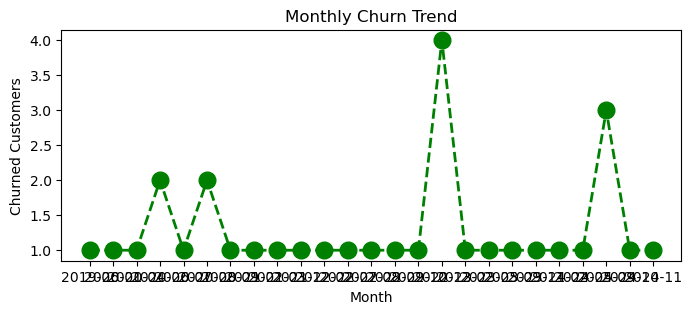

In [66]:
# 4.1 Monthly Churn Trend
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green', marker='o',linestyle='dashed',linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

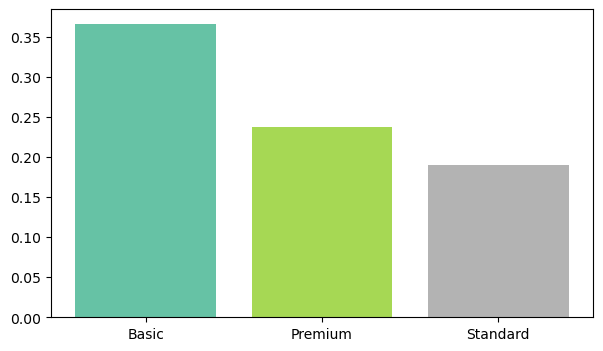

In [67]:
# 4.2 Churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
# colors = ['blue','purple','green']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

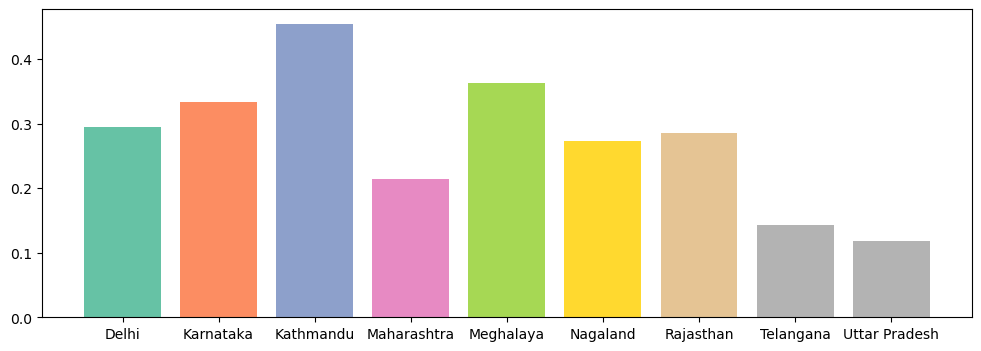

In [68]:
# 4.3 Churn by states
churn_state = df_visual.groupby('state')['churn_flag'].mean()
# colors = ['blue','purple','green']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_state)))
plt.figure(figsize=(12,4))
plt.bar(churn_state.index,churn_state.values,color=colors)
plt.show()

In [69]:
# 5. Visualization  by Seaborn

In [70]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [71]:
import warnings
warnings.filterwarnings('ignore')

In [72]:
# Incorrect method of encoding - as numbers are not assigned based on priorties
df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorial_col = df_visual[['plan_type', 'contract_type','churn_risk']]
for cols in categorial_col:
    df_encoded[cols] = df_encoded[cols].astype('category').cat.codes

<Axes: >

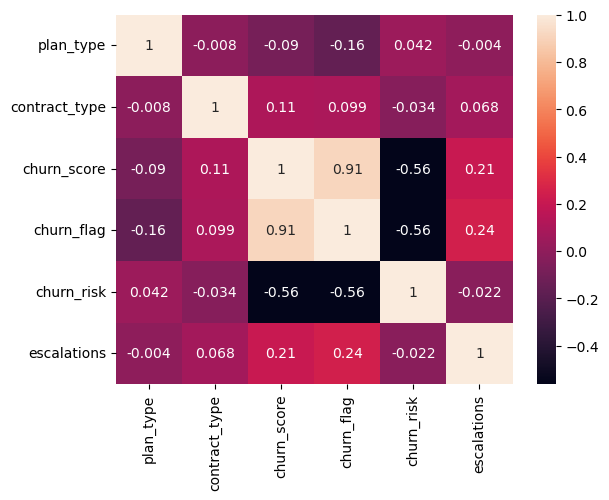

In [73]:
# Hearmap (correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)

In [74]:
# Incorrect method of encoding - as numbers are not assigned based on priorties
df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mapping = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk': ['low','medium','high']
}
for cols,order in order_mapping.items():
    df_encoded[cols] = pd.Categorical(df_encoded[cols].astype('category'),categories=order,ordered=True).codes

<Axes: >

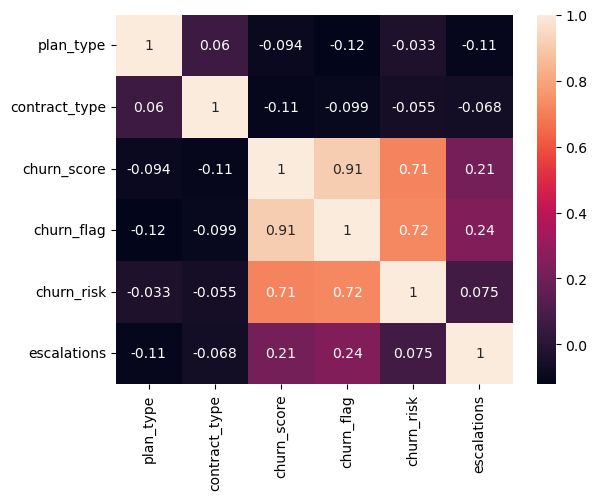

In [75]:
sns.heatmap(df_encoded.corr(),annot=True)

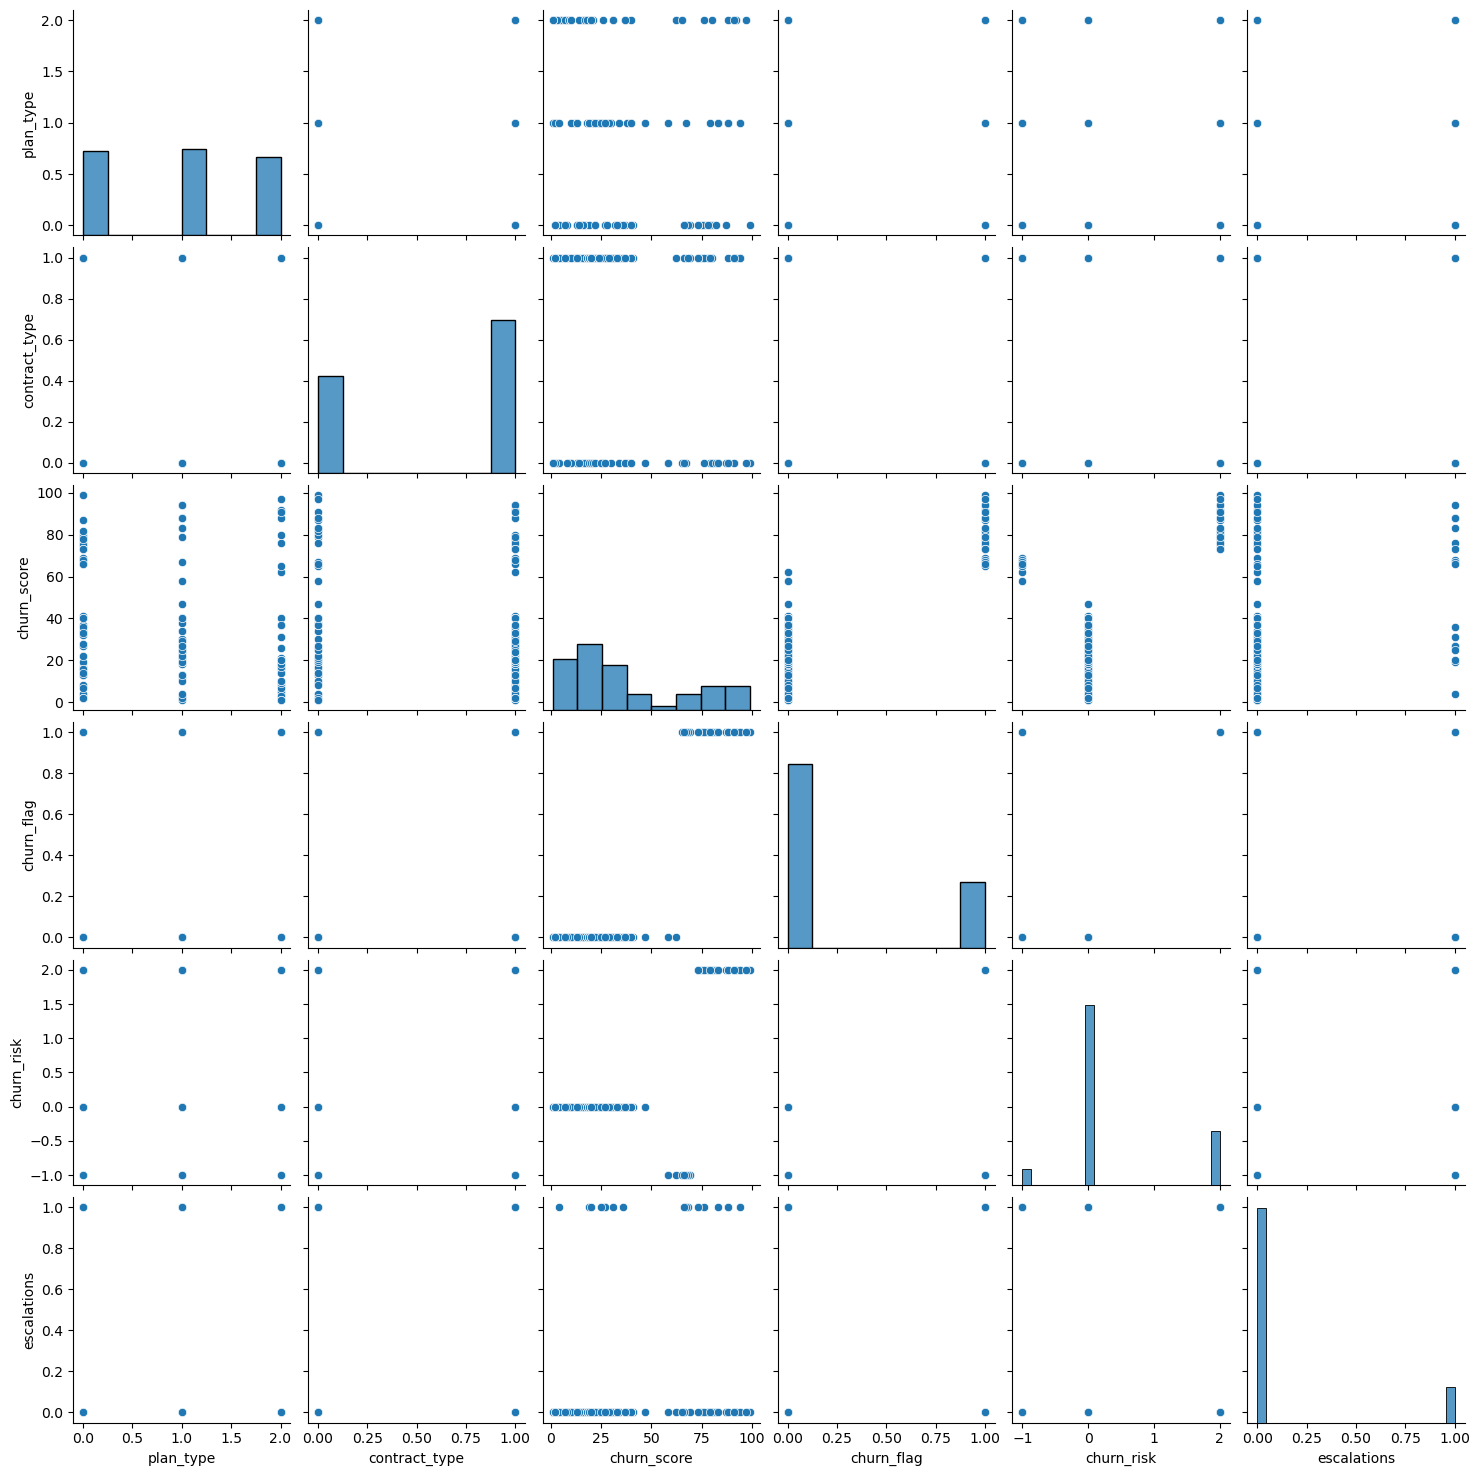

In [76]:
#pairplot - to find relationship in dataset
sns.pairplot(df_encoded)

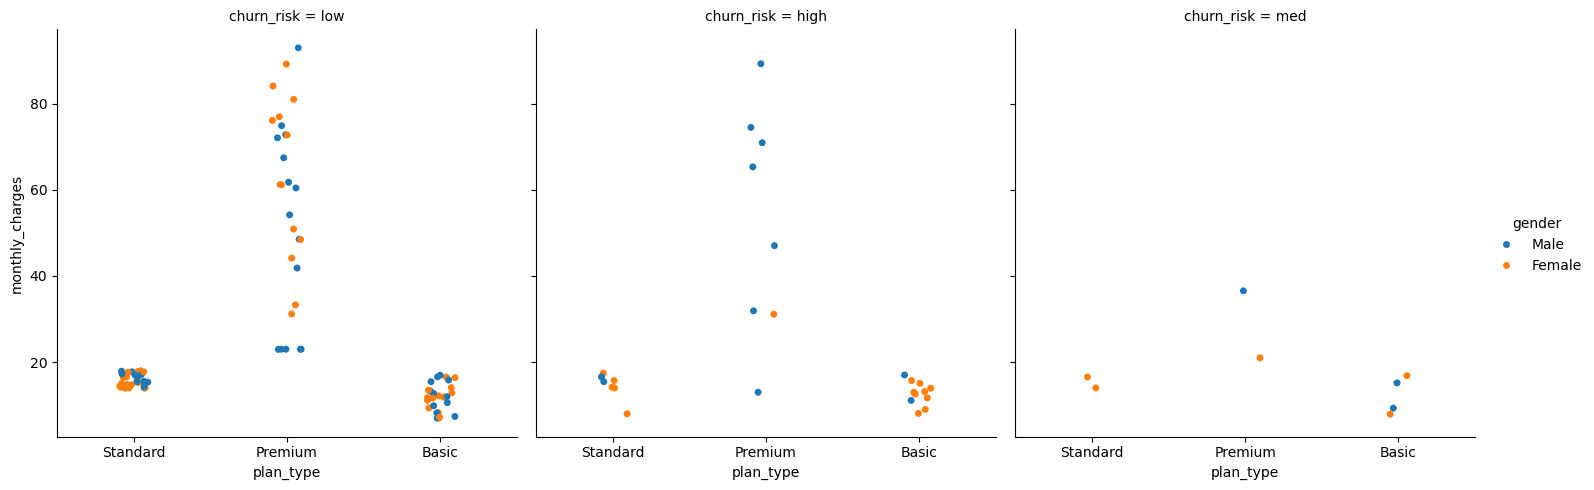

In [77]:
#catplot/Facegrid plot - multi-dim comparison
sns.catplot(data = df_visual,
            x = 'plan_type',
            y = 'monthly_charges',
            hue = 'gender',
            col = 'churn_risk')


In [78]:
# Pivot Table

In [79]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.365854
1,Premium,0.236842
2,Standard,0.190476


In [80]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc = {
    'monthly_charges':'sum',
    'customerid': 'count',
    'churn_flag' : 'mean'
    }   
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.365854,41,498.71
1,Premium,0.236842,38,2053.13
2,Standard,0.190476,42,652.97


In [81]:
# Working with SQL in python (pandas)

In [82]:
# Create the connect
conn = sqlite3.connect('test_database.sqlite')

# Table details 
conn.execute("DROP TABLE IF EXISTS users")
conn.execute ("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

#commit changes
conn.commit()

In [83]:
# Insert Data
cursor = conn.cursor()

# Write SQL query to insert records in the data
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Shiva','Nepal',2300),
            ('Ram','India',4000),
            ('Shyam','India',3000)
    """
)

#commit changes
conn.commit()
print('Data Insereted Successfully!')

Data Insereted Successfully!


In [84]:
# Check inserted data into table
conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users"""
df_results = pd.read_sql(query,conn)
df_results

,first_name,country,budget
0,Shiva,Nepal,2300
1,Ram,India,4000
2,Shyam,India,3000


In [85]:
# Aggregation
query = """
            SELECT country,SUM(budget) As Total_budget
            FROM users
            GROUP BY country
            """
df_agg = pd.read_sql(query,conn)
df_agg

,country,Total_budget
0,India,7000
1,Nepal,2300


In [86]:
conn.close()